# Classical Baseline Detectors

Before training a temporal model, establish simple baselines.

Goal: evaluate simple anomaly detection baselines before moving to temporal models.

Methods:
1. Rolling Z-Score
2. PCA Reconstruction Error
3. Isolation Forest

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

plt.style.use("default")

## Load Windowed Telemetry

Window format:

(num_windows, window_size, num_sensors)

In [24]:
X_train = np.load("data/X_train.npy")
X_val   = np.load("data/X_val.npy")
X_test  = np.load("data/X_test.npy")

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (233, 80, 12)
Val shape: (68, 80, 12)
Test shape: (68, 80, 12)


## Load Windowed Telemetry

Window format:

(num_windows, window_size, num_sensors)

In [25]:
n_train, T, n_features = X_train.shape
n_test = X_test.shape[0]

X_train_flat = X_train.reshape(n_train, T * n_features)
X_test_flat  = X_test.reshape(n_test, T * n_features)

print("Flattened train shape:", X_train_flat.shape)

Flattened train shape: (233, 960)


##  Global Z-Score Baseline

Mean and standard deviation are computed from the training set.

Window score is taken as the maximum absolute z-score across
all sensors and time steps in the window.

### Z-Score Visualization

New Z threshold: 24.114311103571943
Z anomalies detected: 0
Min Z-score: 5.0662280511898174
25th percentile: 8.811911769278014
50th percentile: 12.861903880393868
75th percentile: 24.114311103571943
Max Z-score: 24.114311103571943


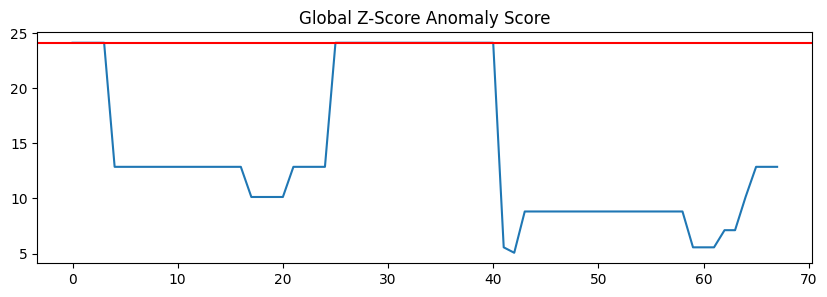

In [26]:
# Compute mean/std per sensor (from TRAIN)
train_mean = X_train.mean(axis=(0,1))
train_std  = X_train.std(axis=(0,1))

epsilon = 1e-4
train_std = np.where(train_std < epsilon, epsilon, train_std)

train_mean = train_mean.reshape(1,1,-1)
train_std  = train_std.reshape(1,1,-1)

#  TEST Z SCORE 
z_scores_test = np.abs((X_test - train_mean) / train_std)
z_window_score = z_scores_test.max(axis=(1,2))

#  TRAIN Z SCORE (for threshold)
z_scores_train = np.abs((X_train - train_mean) / train_std)
z_train_window_score = z_scores_train.max(axis=(1,2))

z_threshold = np.percentile(z_train_window_score, 95)
z_anomalies = z_window_score > z_threshold

print("New Z threshold:", z_threshold)
print("Z anomalies detected:", z_anomalies.sum())
print("Min Z-score:", z_window_score.min())
print("25th percentile:", np.percentile(z_window_score, 25))
print("50th percentile:", np.percentile(z_window_score, 50))
print("75th percentile:", np.percentile(z_window_score, 75))
print("Max Z-score:", z_window_score.max())

#  Visualization 
plt.figure(figsize=(10,3))
plt.plot(z_window_score)
plt.axhline(z_threshold, color="red")
plt.title("Global Z-Score Anomaly Score")
plt.show()

## PCA Reconstruction Baseline

Train PCA on flattened training windows.

Anomaly score = reconstruction error.

In [27]:
# Fit PCA
pca = PCA(n_components=0.95)
pca.fit(X_train_flat)

# Training reconstruction error
X_train_recon = pca.inverse_transform(pca.transform(X_train_flat))
train_error = np.mean((X_train_flat - X_train_recon)**2, axis=1)

# Test reconstruction error
X_test_recon = pca.inverse_transform(pca.transform(X_test_flat))
pca_error = np.mean((X_test_flat - X_test_recon)**2, axis=1)

# Threshold from training distribution
pca_threshold = np.percentile(train_error, 95)

pca_anomalies = pca_error > pca_threshold

print("PCA anomalies detected:", pca_anomalies.sum())
print("PCA threshold:", pca_threshold)

PCA anomalies detected: 65
PCA threshold: 0.15910527307173267


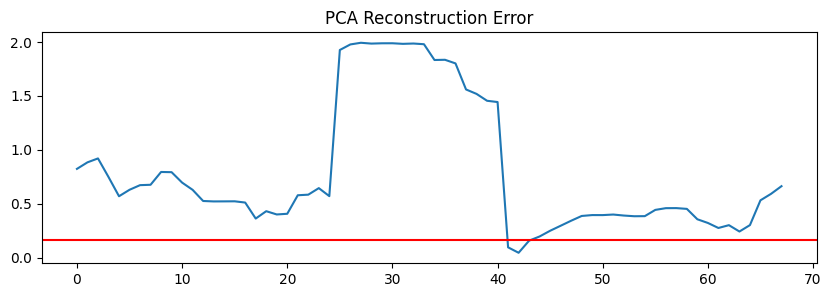

In [28]:
plt.figure(figsize=(10,3))
plt.plot(pca_error)
plt.axhline(pca_threshold, color="red")
plt.title("PCA Reconstruction Error")
plt.show()

In [29]:
print("Min PCA error:", pca_error.min())
print("25th percentile:", np.percentile(pca_error, 25))
print("50th percentile:", np.percentile(pca_error, 50))
print("75th percentile:", np.percentile(pca_error, 75))
print("Max PCA error:", pca_error.max())

Min PCA error: 0.04484516128240738
25th percentile: 0.3892769729799965
50th percentile: 0.5504175542992495
75th percentile: 0.8928599751206879
Max PCA error: 1.9928719637492671


In [30]:
from sklearn.ensemble import IsolationForest

Isolation Forest anomalies detected: 0


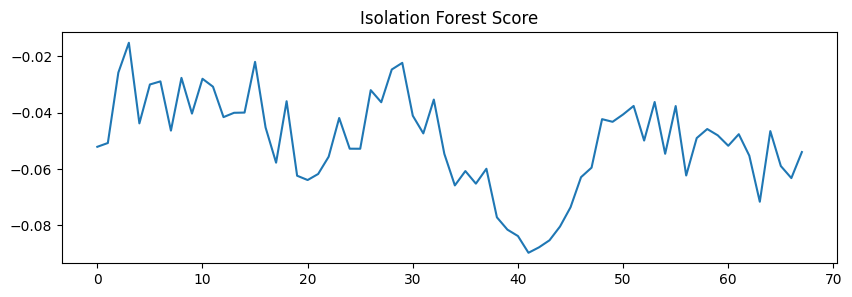

In [31]:
iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(X_train_flat)

iso_scores = -iso.decision_function(X_test_flat)
iso_preds  = iso.predict(X_test_flat)

iso_anomalies = iso_preds == -1

print("Isolation Forest anomalies detected:", iso_anomalies.sum())

plt.figure(figsize=(10,3))
plt.plot(iso_scores)
plt.title("Isolation Forest Score")
plt.show()

In [32]:
print("Min ISO score:", iso_scores.min())
print("Max ISO score:", iso_scores.max())
print("Mean ISO score:", iso_scores.mean())

Min ISO score: -0.08968864402455962
Max ISO score: -0.015267477207976998
Mean ISO score: -0.05026455435516508


In [33]:
print("Unique ISO predictions:", np.unique(iso_preds))

Unique ISO predictions: [1]


## Baseline Observations

Z-score reacts strongly to distribution shifts but produces many false positives.

PCA captures structural deviations through reconstruction error,
but still ignores temporal ordering.

Isolation Forest performs poorly once the time series is flattened,
likely due to the very high dimensional feature space.

These limitations motivate a temporal model that can capture
sequence dynamics directly.